In [77]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/soccer-players.csv"
df=pd.read_csv(url)

In [78]:
df.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='object')

In [79]:
df = df[['name','country_of_birth', 'date_of_birth', 'position', 'height_in_cm']]


In [80]:
df.head()

,name,country_of_birth,date_of_birth,position,height_in_cm
0,Miroslav Klose,Poland,1978-06-09 00:00:00,Attack,184.0
1,Roman Weidenfeller,Germany,1980-08-06 00:00:00,Goalkeeper,190.0
2,Dimitar Berbatov,Bulgaria,1981-01-30 00:00:00,Attack,NaN
3,Lúcio,Brazil,1978-05-08 00:00:00,Defender,NaN
4,Tom Starke,East Germany (GDR),1981-03-18 00:00:00,Goalkeeper,194.0


([<matplotlib.axis.YTick at 0x141ee25d0>], [Text(0, 1, 'Players')])

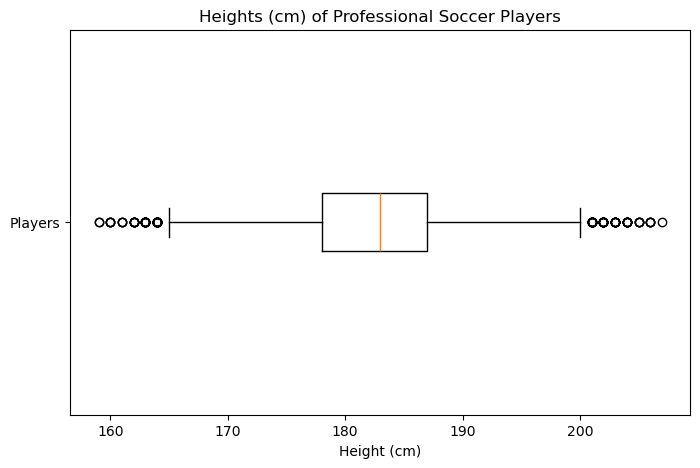

In [81]:
plt.figure(figsize=(8,5)) #plt acceps array-like information 
plt.boxplot(df.loc[df['height_in_cm'] > 150, 'height_in_cm'].dropna(), vert=False) #second call of height in cm is just 
#calling to show the data points, if not the whole df (all columns) would show with the heights >150
plt.title('Heights (cm) of Professional Soccer Players')
plt.xlabel('Height (cm)')
plt.yticks(ticks=[1], labels=['Players']) #players are at the 1 index for ticks 

In [82]:
df.loc[df['height_in_cm'] > 185, ['position', 'name']]
# calls the position and name columns for the entries that height > 185

,position,name
1,Goalkeeper,Roman Weidenfeller
4,Goalkeeper,Tom Starke
8,Goalkeeper,Marc Ziegler
9,Attack,Roque Santa Cruz
17,Midfield,Sebastian Kehl
...,...,...
32370,Goalkeeper,Valeriy Kosivskyi
32372,Attack,Fedir Zadorozhnyi
32374,Attack,Ahmet Mert Koşar
32380,Midfield,Yegor Tsevukh


([<matplotlib.axis.XTick at 0x141cc6ad0>,
 [Text(1, 0, 'Attack'),
  Text(2, 0, 'Goalkeeper'),
  Text(3, 0, 'Defender'),
  Text(4, 0, 'Midfield'),
  Text(5, 0, 'Missing')])

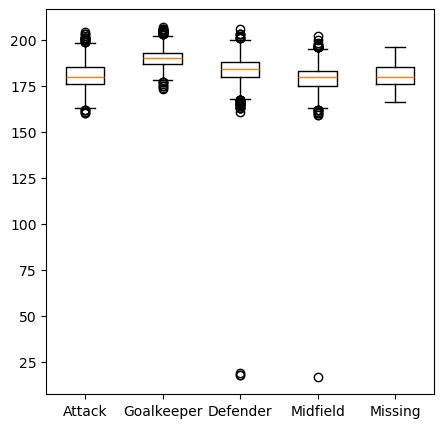

In [83]:
plt.figure(figsize=(5,5)) #5 inches x 5 inches
pos = df['position'].unique()
data = df.loc[df['height_in_cm'] > 150]
data = [df.loc[df['position'] == p, 'height_in_cm'].dropna() for p in pos]
plt.boxplot(data)

plt.xticks(ticks=range(1, len(pos)+1), labels=pos.tolist())

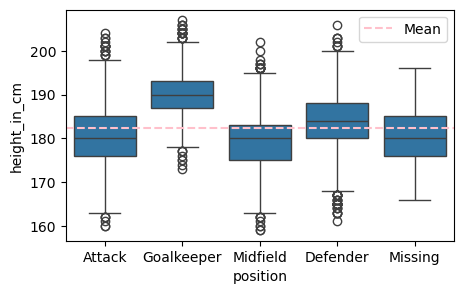

In [84]:
plt.figure(figsize=(5,3))
df = df.loc[df['height_in_cm']>150]
ht_boxes = sns.boxplot(data=df, x='position', y='height_in_cm')
plt.axhline(y=df['height_in_cm'].mean(), color = 'pink', linestyle = '--', label = 'Mean')
plt.legend()

In [85]:
import scipy.stats as stats 
def multiplot(df:pd.DataFrame, col:str, xlabel:str):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x='height_in_cm', ax=ax1, color='lightpink')
    hist = sns.histplot(data=df, x='height_in_cm', ax=ax2, color='teal', kde=True)
    sk = stats.skew(df[col], nan_policy='omit')
    kurt = stats.kurtosis(df[col], nan_policy='omit')
    box.set(xlabel='', xticks = [], yticks=[])
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    hist.set(xlabel=xlabel)
    text = f'Skew: {sk:.3f}\nKurtosis: {kurt: .3f}'
    plt.text( 
        x=0.2, 
        y=0.7,
        s=text, 
        transform=plt.gca().transAxes, 
        bbox={'boxstyle': 'round, pad=0.5', 'fc': 'white'},
        ha='center'
)
box.set(title='Heights of Professional Soccer Players')
plt.show()

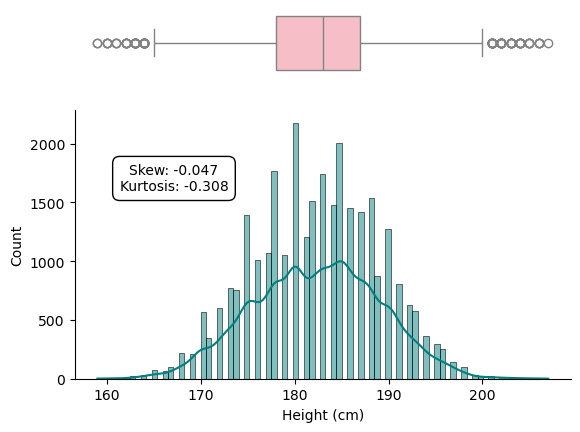

In [86]:
multiplot(df=df, col='height_in_cm', xlabel='Height (cm)')

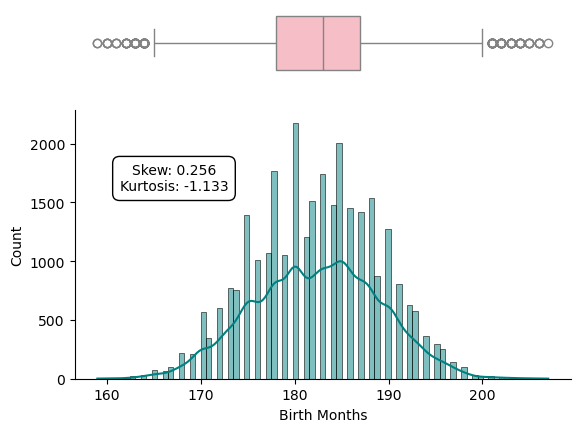

In [87]:
df['month'] = pd.to_datetime(df['date_of_birth']).dt.month
multiplot(df=df, col='month', xlabel='Birth Months')